# CPE 628 - HW1 Part A: TensorFlow / Keras

Two tasks:
1. **Linear regression** on the California Housing dataset (predict median house value)
2. **MNIST digit classification** with a multi-layer perceptron (MLP)

The first half of each task is the given code, run as-is. After that there's a **tuning** section where I change hyperparameters and compare.

> Runs locally in VS Code. Pick the **Python (CPE628)** kernel (top right of the notebook). No GPU here, so everything trains on the CPU.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print("GPU:", tf.config.list_physical_devices("GPU") or "none (CPU only)")

# Set random seeds for consistent reproducibility across runs
tf.keras.utils.set_random_seed(42)

TensorFlow version: 2.21.0
Keras version: 3.15.1
GPU: none (CPU only)


---
# Task 1: Linear Regression (California Housing)

8 input features (median income, house age, avg rooms, avg bedrooms, population, avg occupancy, latitude, longitude). Target is median house value in units of $100k.

In [2]:
# 1. Load dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target
print("X shape:", X.shape, "| y shape:", y.shape)
print("Features:", housing.feature_names)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X shape: (20640, 8) | y shape: (20640,)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [3]:
# 4. Build single-layer linear regression model
# Using explicit keras.Input instead of input_shape on the Dense layer
linear_model = keras.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(1),  # No activation function implies linear regression
    ],
    name="linear_regression_model",
)

linear_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"],
)
linear_model.summary()

Model: "linear_regression_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 5. Train model
history_linear = linear_model.fit(
    X_train_scaled,
    y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/60
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.6370 - mae: 1.2650 - val_loss: 0.9015 - val_mae: 0.6548
Epoch 2/60
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6538 - mae: 0.5629 - val_loss: 0.5918 - val_mae: 0.5490
Epoch 3/60
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5522 - mae: 0.5367 - val_loss: 0.5650 - val_mae: 0.5446
Epoch 4/60
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5323 - mae: 0.5301 - val_loss: 0.5537 - val_mae: 0.5407
Epoch 5/60
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5233 - mae: 0.5269 - val_loss: 0.5490 - val_mae: 0.5399
Epoch 6/60
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5196 - mae: 0.5264 - val_loss: 0.5472 - val_mae: 0.5399
Epoch 7/60
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5181 - mae: 0.5266 - val_loss: 0.5464 - val_mae: 0.5402
Epoch 8/60
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5176 - mae: 0.5269 - val_loss: 0.5461 - val_mae: 0.5405
Epoch 9/60
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

[Linear Model] Test MSE: 0.5485 | Test MAE: 0.5348


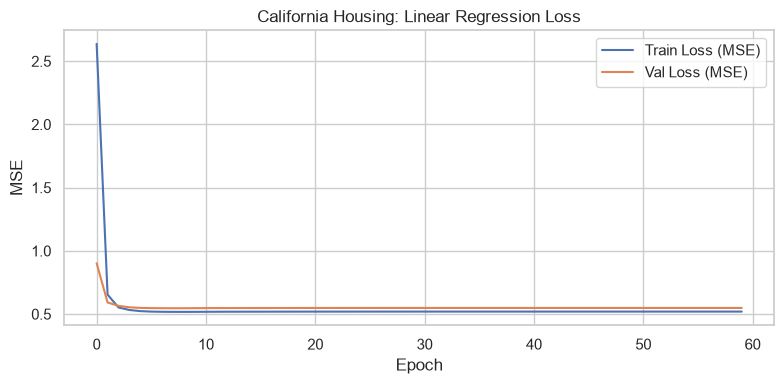

In [5]:
# 6. Evaluate on unseen test data
test_loss, test_mae = linear_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n[Linear Model] Test MSE: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

# 7. Plot loss curves
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))
plt.plot(history_linear.history["loss"], label="Train Loss (MSE)")
plt.plot(history_linear.history["val_loss"], label="Val Loss (MSE)")
plt.title("California Housing: Linear Regression Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

### Extra: what did the model actually learn?
Since it's just `y = w.x + b`, the weights tell us which features matter most (features are standardized so the weights are comparable).

Latitude     -0.869
Longitude    -0.862
AveRooms     -0.317
AveOccup     -0.057
Population   -0.039
HouseAge      0.103
AveBedrms     0.324
MedInc        0.820
dtype: float32
bias: 2.066


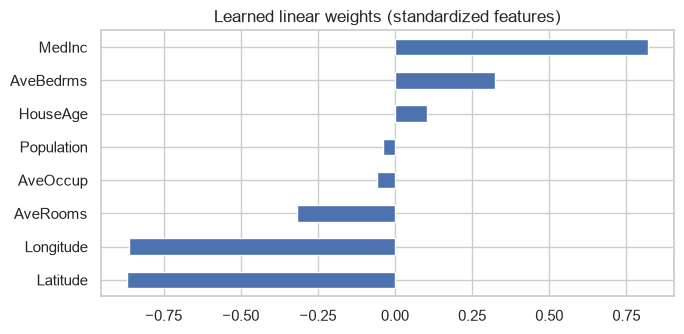

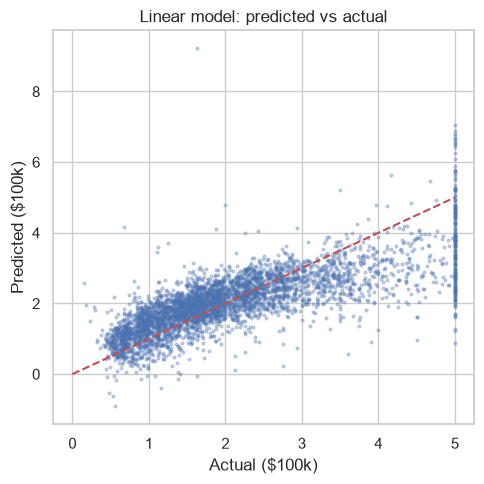

In [6]:
w, b = linear_model.layers[-1].get_weights()
weights = pd.Series(w.flatten(), index=housing.feature_names).sort_values()
print(weights.round(3))
print("bias:", round(float(b[0]), 3))

weights.plot(kind="barh", figsize=(7, 3.5), title="Learned linear weights (standardized features)")
plt.tight_layout()
plt.show()

# predicted vs actual
preds = linear_model.predict(X_test_scaled, verbose=0).flatten()
plt.figure(figsize=(5, 5))
plt.scatter(y_test, preds, s=4, alpha=0.3)
plt.plot([0, 5], [0, 5], "r--")
plt.xlabel("Actual ($100k)")
plt.ylabel("Predicted ($100k)")
plt.title("Linear model: predicted vs actual")
plt.tight_layout()
plt.show()

## Task 1 Tuning

**Experiment 1 - learning rate.** Same model, 60 epochs, batch 64, only the Adam learning rate changes.

lr=0.001  -> test MSE 0.5616, test MAE 0.5338
lr=0.01   -> test MSE 0.5485, test MAE 0.5348
lr=0.1    -> test MSE 0.7247, test MAE 0.5756


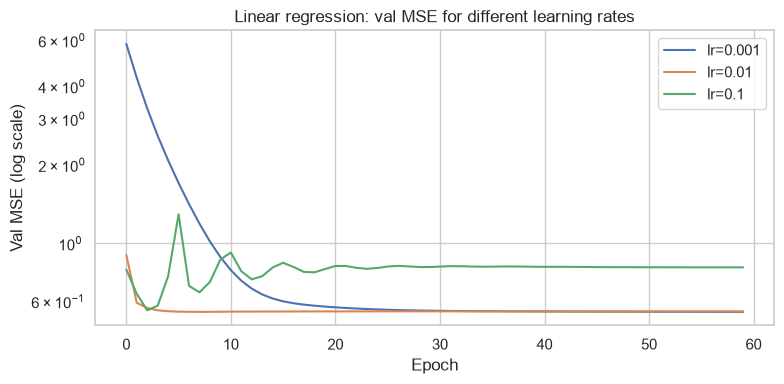

,learning_rate,test_MSE,test_MAE,final_val_MSE
0,0.001,0.561554,0.533777,0.546043
1,0.010,0.548520,0.534791,0.548561
2,0.100,0.724677,0.575586,0.808906


In [7]:
def build_linear(lr):
  m = keras.Sequential([layers.Input(shape=(X_train.shape[1],)), layers.Dense(1)])
  m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse", metrics=["mae"])
  return m

lin_results = []
lin_histories = {}
for lr in [0.001, 0.01, 0.1]:
  tf.keras.utils.set_random_seed(42)
  m = build_linear(lr)
  h = m.fit(X_train_scaled, y_train, epochs=60, batch_size=64,
            validation_split=0.2, verbose=0)
  mse, mae = m.evaluate(X_test_scaled, y_test, verbose=0)
  lin_histories[f"lr={lr}"] = h.history["val_loss"]
  lin_results.append({"learning_rate": lr, "test_MSE": mse, "test_MAE": mae,
                      "final_val_MSE": h.history["val_loss"][-1]})
  print(f"lr={lr:<6} -> test MSE {mse:.4f}, test MAE {mae:.4f}")

plt.figure(figsize=(8, 4))
for k, v in lin_histories.items():
  plt.plot(v, label=k)
plt.yscale("log")
plt.title("Linear regression: val MSE for different learning rates")
plt.xlabel("Epoch")
plt.ylabel("Val MSE (log scale)")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(lin_results)

**Experiment 2 - batch size.** lr fixed at 0.01, try small vs big batches.

In [8]:
bs_results = []
for bs in [16, 64, 256]:
  tf.keras.utils.set_random_seed(42)
  m = build_linear(0.01)
  h = m.fit(X_train_scaled, y_train, epochs=60, batch_size=bs,
            validation_split=0.2, verbose=0)
  mse, mae = m.evaluate(X_test_scaled, y_test, verbose=0)
  bs_results.append({"batch_size": bs, "test_MSE": mse, "test_MAE": mae})
  print(f"batch={bs:<4} -> test MSE {mse:.4f}, test MAE {mae:.4f}")

pd.DataFrame(bs_results)

batch=16   -> test MSE 0.5715, test MAE 0.5343
batch=64   -> test MSE 0.5485, test MAE 0.5348
batch=256  -> test MSE 0.5554, test MAE 0.5349


,batch_size,test_MSE,test_MAE
0,16,0.571500,0.534265
1,64,0.548520,0.534791
2,256,0.555423,0.534889


**Experiment 3 - is a straight line the problem?** Add two hidden ReLU layers (so it's not linear anymore) and see how much better it gets. Everything else (lr, epochs, batch size) stays the same.

Linear model  -> Test MSE: 0.5485 | MAE: 0.5348
Small MLP     -> Test MSE: 0.2897 | MAE: 0.3744


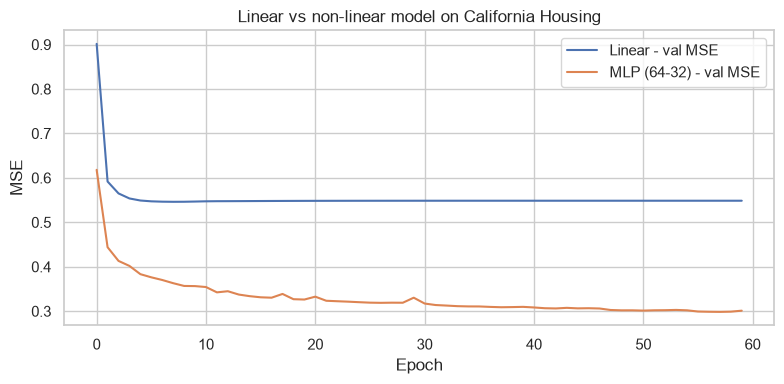

In [9]:
tf.keras.utils.set_random_seed(42)
mlp_reg = keras.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ],
    name="small_mlp_regressor",
)
mlp_reg.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
h_mlp = mlp_reg.fit(X_train_scaled, y_train, epochs=60, batch_size=64,
                    validation_split=0.2, verbose=0)
mlp_mse, mlp_mae = mlp_reg.evaluate(X_test_scaled, y_test, verbose=0)

lin_mse, lin_mae = linear_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Linear model  -> Test MSE: {lin_mse:.4f} | MAE: {lin_mae:.4f}")
print(f"Small MLP     -> Test MSE: {mlp_mse:.4f} | MAE: {mlp_mae:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(history_linear.history["val_loss"], label="Linear - val MSE")
plt.plot(h_mlp.history["val_loss"], label="MLP (64-32) - val MSE")
plt.title("Linear vs non-linear model on California Housing")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

---
# Task 2: MNIST Handwritten Digit Classification

60k training / 10k test grayscale images, 28x28 pixels, labels 0-9.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
train: (60000, 28, 28) | test: (10000, 28, 28)


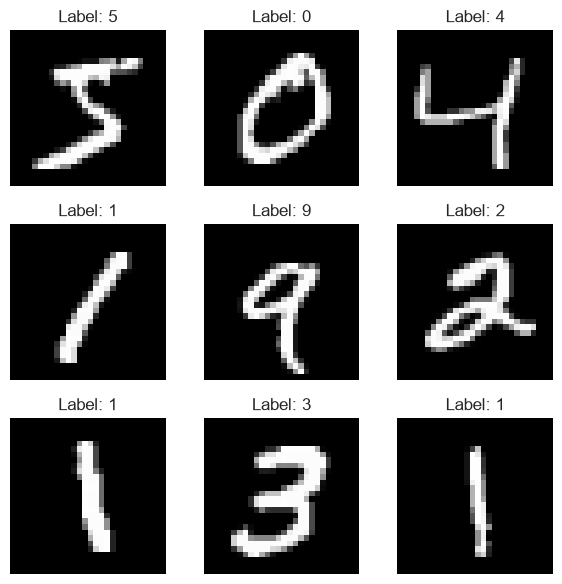

In [10]:
# 1. Load dataset
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = (
    keras.datasets.mnist.load_data()
)
print("train:", X_train_mnist.shape, "| test:", X_test_mnist.shape)

# 2. Display sample images
plt.figure(figsize=(6, 6))
for i in range(9):
  plt.subplot(3, 3, i + 1)
  plt.imshow(X_train_mnist[i], cmap="gray")
  plt.title(f"Label: {y_train_mnist[i]}")
  plt.axis("off")
plt.tight_layout()
plt.show()

# 3. Scale pixel values to range [0.0, 1.0]
# Keep the 2D (28, 28) image format and delegate flattening to layers.Flatten
X_train_mnist = X_train_mnist.astype("float32") / 255.0
X_test_mnist = X_test_mnist.astype("float32") / 255.0

In [11]:
# 4. Define classification architecture
def build_mnist_model() -> keras.Model:
  model = keras.Sequential(
      [
          layers.Input(shape=(28, 28)),
          layers.Flatten(),
          layers.Dense(512, activation="relu"),
          layers.Dropout(0.2),
          layers.Dense(256, activation="relu"),
          layers.Dropout(0.2),
          layers.Dense(128, activation="relu"),
          layers.Dropout(0.2),
          # Use raw logits (no softmax) for better numerical stability during training
          layers.Dense(10),
      ],
      name="mnist_classifier",
  )

  model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=1e-3),
      loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
      metrics=["accuracy"],
  )
  return model


mnist_model = build_mnist_model()
mnist_model.summary()

Model: "mnist_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 5. Fit model
history_mnist = mnist_model.fit(
    X_train_mnist,
    y_train_mnist,
    validation_data=(X_test_mnist, y_test_mnist),
    epochs=15,
    batch_size=128,
    verbose=1,
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9099 - loss: 0.2966 - val_accuracy: 0.9652 - val_loss: 0.1146
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9639 - loss: 0.1203 - val_accuracy: 0.9756 - val_loss: 0.0774
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9732 - loss: 0.0883 - val_accuracy: 0.9771 - val_loss: 0.0740
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9791 - loss: 0.0687 - val_accuracy: 0.9788 - val_loss: 0.0651
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9821 - loss: 0.0572 - val_accuracy: 0.9811 - val_loss: 0.0697
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9833 - loss: 0.0528 - val_accuracy: 0.9791 - val_loss: 0.0664
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9863 - loss: 0.0433 - val_accuracy: 0.9810 - val_loss: 0.0631
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9878 - loss: 0.0390 - val_accu

[MNIST Model] Test Accuracy: 98.24%


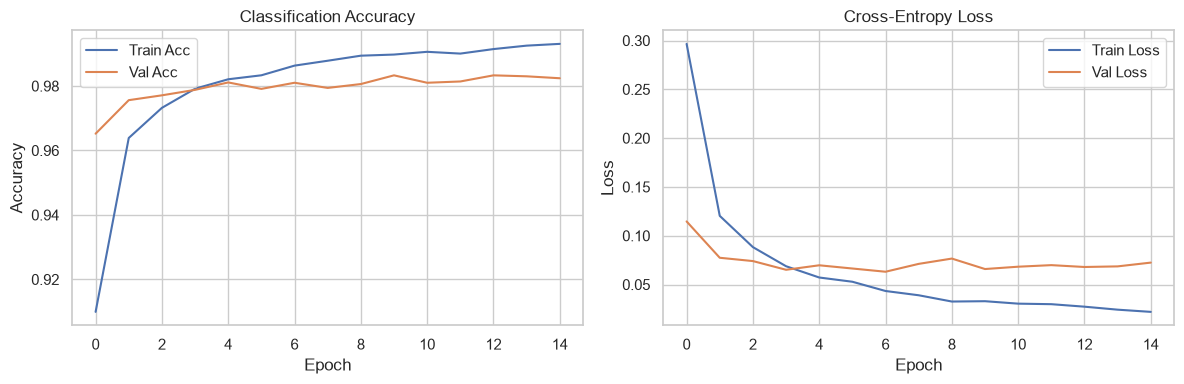

In [13]:
# 6. Evaluate model
test_loss, test_acc = mnist_model.evaluate(
    X_test_mnist, y_test_mnist, verbose=0
)
print(f"\n[MNIST Model] Test Accuracy: {test_acc * 100:.2f}%")

# 7. Plot training progress
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_mnist.history["accuracy"], label="Train Acc")
axes[0].plot(history_mnist.history["val_accuracy"], label="Val Acc")
axes[0].set_title("Classification Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_mnist.history["loss"], label="Train Loss")
axes[1].plot(history_mnist.history["val_loss"], label="Val Loss")
axes[1].set_title("Cross-Entropy Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

### Extra: where does the model mess up?
Confusion matrix + a few of the misclassified digits.

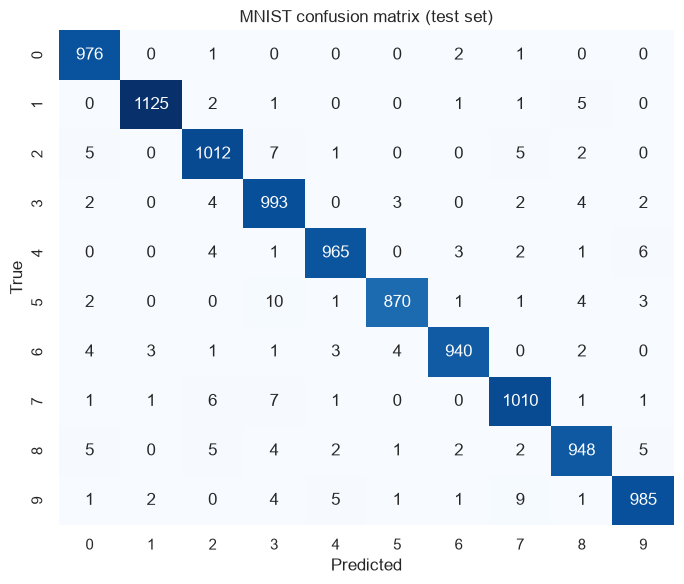

176 wrong out of 10000


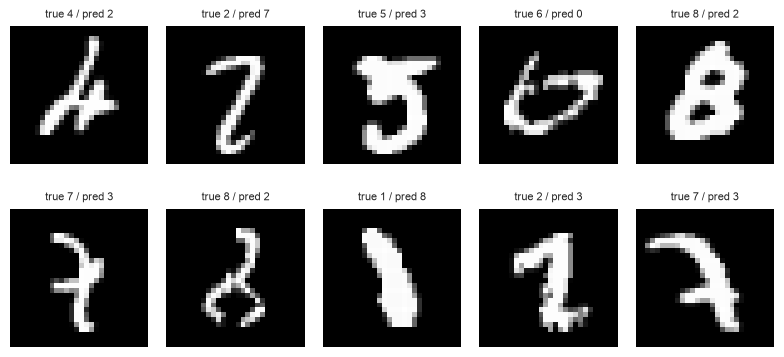

In [14]:
from sklearn.metrics import confusion_matrix

logits = mnist_model.predict(X_test_mnist, verbose=0)
pred_labels = logits.argmax(axis=1)
cm = confusion_matrix(y_test_mnist, pred_labels)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST confusion matrix (test set)")
plt.tight_layout()
plt.show()

wrong = np.where(pred_labels != y_test_mnist)[0]
print(f"{len(wrong)} wrong out of {len(y_test_mnist)}")
plt.figure(figsize=(8, 4))
for i, idx in enumerate(wrong[:10]):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_test_mnist[idx], cmap="gray")
  plt.title(f"true {y_test_mnist[idx]} / pred {pred_labels[idx]}", fontsize=8)
  plt.axis("off")
plt.tight_layout()
plt.show()

## Task 2 Tuning

The given code uses the **test set as validation data**, which is fine for watching the curves but it's kind of cheating if you use it to pick hyperparameters. So for tuning I hold out 10% of the *training* set as validation and only look at the test set at the very end.

Each config trains for 10 epochs (to save time). I change one thing at a time from the baseline (lr=1e-3, dropout=0.2, batch=128).

In [15]:
def build_mnist_tuned(lr=1e-3, dropout=0.2, units=(512, 256, 128)):
  model = keras.Sequential([layers.Input(shape=(28, 28)), layers.Flatten()])
  for u in units:
    model.add(layers.Dense(u, activation="relu"))
    if dropout > 0:
      model.add(layers.Dropout(dropout))
  model.add(layers.Dense(10))
  model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=lr),
      loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
      metrics=["accuracy"],
  )
  return model


configs = [
    {"name": "baseline",        "lr": 1e-3, "dropout": 0.2, "batch": 128, "units": (512, 256, 128)},
    {"name": "lr=1e-2",         "lr": 1e-2, "dropout": 0.2, "batch": 128, "units": (512, 256, 128)},
    {"name": "lr=1e-4",         "lr": 1e-4, "dropout": 0.2, "batch": 128, "units": (512, 256, 128)},
    {"name": "no dropout",      "lr": 1e-3, "dropout": 0.0, "batch": 128, "units": (512, 256, 128)},
    {"name": "dropout=0.5",     "lr": 1e-3, "dropout": 0.5, "batch": 128, "units": (512, 256, 128)},
    {"name": "batch=32",        "lr": 1e-3, "dropout": 0.2, "batch": 32,  "units": (512, 256, 128)},
    {"name": "smaller (128)",   "lr": 1e-3, "dropout": 0.2, "batch": 128, "units": (128,)},
]

mnist_results = []
mnist_histories = {}
for cfg in configs:
  tf.keras.utils.set_random_seed(42)
  m = build_mnist_tuned(cfg["lr"], cfg["dropout"], cfg["units"])
  h = m.fit(X_train_mnist, y_train_mnist, validation_split=0.1,
            epochs=10, batch_size=cfg["batch"], verbose=0)
  _, t_acc = m.evaluate(X_test_mnist, y_test_mnist, verbose=0)
  mnist_histories[cfg["name"]] = h.history
  mnist_results.append({
      "config": cfg["name"],
      "params": m.count_params(),
      "train_acc": h.history["accuracy"][-1],
      "val_acc": h.history["val_accuracy"][-1],
      "best_val_acc": max(h.history["val_accuracy"]),
      "test_acc": t_acc,
      "val_loss_min_epoch": int(np.argmin(h.history["val_loss"])) + 1,
  })
  print(f"{cfg['name']:<15} val acc {h.history['val_accuracy'][-1]*100:.2f}% | test acc {t_acc*100:.2f}%")

mnist_df = pd.DataFrame(mnist_results)
mnist_df.style.format({"train_acc": "{:.4f}", "val_acc": "{:.4f}",
                       "best_val_acc": "{:.4f}", "test_acc": "{:.4f}"})

baseline        val acc 98.10% | test acc 98.01%
lr=1e-2         val acc 97.32% | test acc 96.77%
lr=1e-4         val acc 97.88% | test acc 97.60%
no dropout      val acc 97.98% | test acc 97.88%
dropout=0.5     val acc 98.25% | test acc 97.84%
batch=32        val acc 98.42% | test acc 97.97%
smaller (128)   val acc 97.95% | test acc 97.65%


,config,params,train_acc,val_acc,best_val_acc,test_acc,val_loss_min_epoch
0,baseline,567434,0.9890,0.9810,0.9832,0.9801,7
1,lr=1e-2,567434,0.9455,0.9732,0.9732,0.9677,10
2,lr=1e-4,567434,0.9746,0.9788,0.9788,0.9760,10
3,no dropout,567434,0.9939,0.9798,0.9818,0.9788,3
4,dropout=0.5,567434,0.9720,0.9825,0.9825,0.9784,10
5,batch=32,567434,0.9868,0.9842,0.9842,0.9797,5
6,smaller (128),101770,0.9811,0.9795,0.9795,0.9765,10


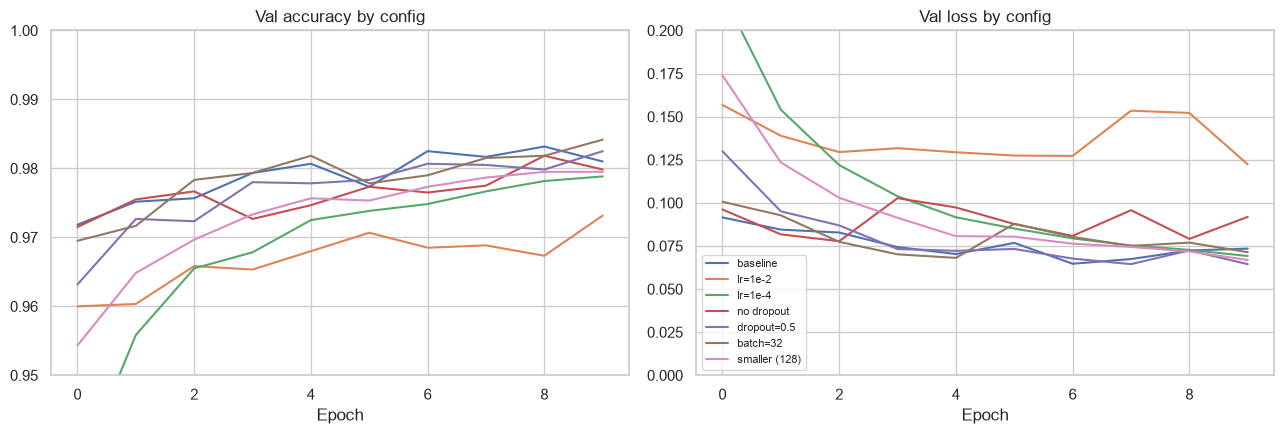

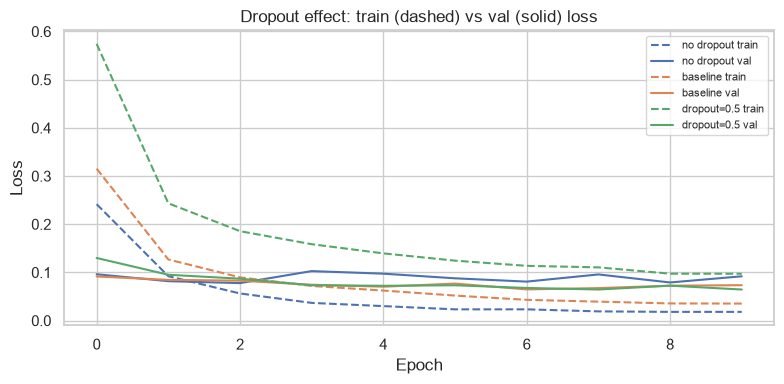

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, h in mnist_histories.items():
  axes[0].plot(h["val_accuracy"], label=name)
  axes[1].plot(h["val_loss"], label=name)
axes[0].set_title("Val accuracy by config")
axes[0].set_xlabel("Epoch")
axes[0].set_ylim(0.95, 1.0)
axes[1].set_title("Val loss by config")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 0.2)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# train vs val gap for the dropout configs (shows overfitting)
plt.figure(figsize=(8, 4))
for name in ["no dropout", "baseline", "dropout=0.5"]:
  h = mnist_histories[name]
  line, = plt.plot(h["loss"], "--", label=f"{name} train")
  plt.plot(h["val_loss"], color=line.get_color(), label=f"{name} val")
plt.title("Dropout effect: train (dashed) vs val (solid) loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Early stopping
The baseline val loss bottoms out before epoch 15 and then creeps back up, so instead of guessing the epoch count, let Keras stop when val loss stops improving and roll back to the best weights.

In [17]:
tf.keras.utils.set_random_seed(42)
es_model = build_mnist_tuned()
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3,
                                           restore_best_weights=True)
h_es = es_model.fit(X_train_mnist, y_train_mnist, validation_split=0.1,
                    epochs=50, batch_size=128, callbacks=[early_stop], verbose=1)
_, es_acc = es_model.evaluate(X_test_mnist, y_test_mnist, verbose=0)
print(f"\nStopped after {len(h_es.history['loss'])} epochs "
      f"(best epoch = {int(np.argmin(h_es.history['val_loss'])) + 1})")
print(f"[Early stopping] Test Accuracy: {es_acc * 100:.2f}%")

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9030 - loss: 0.3153 - val_accuracy: 0.9718 - val_loss: 0.0915
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9619 - loss: 0.1268 - val_accuracy: 0.9752 - val_loss: 0.0845
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9728 - loss: 0.0897 - val_accuracy: 0.9757 - val_loss: 0.0828
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9775 - loss: 0.0719 - val_accuracy: 0.9793 - val_loss: 0.0744
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9804 - loss: 0.0623 - val_accuracy: 0.9807 - val_loss: 0.0703
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9835 - loss: 0.0519 - val_accuracy: 0.9773 - val_loss: 0.0768
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9865 - loss: 0.0430 - val_accuracy: 0.9825 - val_loss: 0.0647
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9873 - loss: 0.0393 - val_accu